In [1]:
# In cell 1

import nltk
from nltk.corpus import treebank
import numpy as np
import re
from collections import Counter
# Removed unused imports: statistics, matplotlib.pyplot

# Download and load the required NLTK corpora and tagger models.
# These downloads are silent (quiet=True) to avoid cluttering the output.
nltk.download('treebank', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

# --- Data Cleaning Function ---
# This regex matches trace tokens and empty categories in the Penn Treebank.
# These are special tokens (like *T*-1, *U*, 0, etc.) that don't represent real words.
TRACE_TOKEN_PATTERN = re.compile(r'^\*.*\*$|^\*$|^\*-?\d+$|^0$')
def is_valid_token(word, pos_tag=None):
    """Checks if a token is valid (not a trace or -NONE- tag)."""
    # Exclude tokens with the -NONE- tag (syntactic placeholders).
    if pos_tag == '-NONE-':
        return False
    # Exclude tokens matching the trace/empty category pattern.
    if TRACE_TOKEN_PATTERN.match(word):
        return False
    return True

# --- Load and Clean Sentences ---
# Get all tagged sentences from the Treebank corpus.
original_tagged_sentences = treebank.tagged_sents()
cleaned_tagged_sentences = []
for sentence in original_tagged_sentences:
    # Remove invalid tokens from each sentence using the function above.
    cleaned_tokens = [(word, pos) for word, pos in sentence if is_valid_token(word, pos)]

    # Only keep sentences that have at least one valid token.
    if cleaned_tokens:
        cleaned_tagged_sentences.append(cleaned_tokens)

# If all sentences are filtered out, raise an error (shouldn't happen unless something is wrong).
if not cleaned_tagged_sentences:
    raise ValueError("No valid sentences found after cleaning. Check the cleaning logic and corpus.")

# --- Prepare Data for Modeling ---
# For consistency with later code, use the variable name 'filtered_tagged_sentences'.
filtered_tagged_sentences = cleaned_tagged_sentences

# Create a list of plain-text sentences (just the words, no POS tags) for BERT input.
filtered_sentences_text = [" ".join([word for word, pos in sentence]) for sentence in filtered_tagged_sentences]

# --- Create Target Variable (Verb Presence) ---
# Define which Penn Treebank POS tags count as verbs.
VERB_TAGS = {'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ'}
y = []
for sentence in filtered_tagged_sentences:
    # Check if any token in the sentence is a verb.
    has_verb = any(pos in VERB_TAGS for word, pos in sentence)
    y.append(1 if has_verb else 0) # 1 = verb present, 0 = no verb
y = np.array(y) 

# --- Gather Basic Statistics on the Final Dataset ---
final_total_sentences = len(filtered_tagged_sentences)
# Flatten all tokens into a single list for counting.
final_all_tokens = [word for sentence in filtered_tagged_sentences for word, pos in sentence]
final_total_tokens = len(final_all_tokens)
final_unique_tokens = set(final_all_tokens)
final_total_unique_tokens = len(final_unique_tokens)

# Count how many sentences have at least one verb and how many have none.
verb_counts = Counter(y)
sentences_with_verbs = verb_counts.get(1, 0) 
sentences_without_verbs = verb_counts.get(0, 0)

# --- Print Statistics ---
print(f"Original tagged sentences from Treebank: {len(original_tagged_sentences)}")
print(f"Sentences after cleaning (used for analysis): {final_total_sentences}")
print("\n--- Statistics for Final Dataset ---")
if final_total_sentences > 0:
    print(f"Sentences containing at least one verb: {sentences_with_verbs} ({sentences_with_verbs/final_total_sentences:.2%})")
    print(f"Sentences containing no verbs: {sentences_without_verbs} ({sentences_without_verbs/final_total_sentences:.2%})")
else:
    print("Sentences containing at least one verb: 0 (0.00%)")
    print("Sentences containing no verbs: 0 (0.00%)")
print(f"Total number of tokens (words): {final_total_tokens}")
print(f"Total number of unique tokens (vocabulary size): {final_total_unique_tokens}")

# Print the shape of the input and target arrays for sanity checking.
print(f"\nShape of text sentences list: ({len(filtered_sentences_text)},)")
print(f"Shape of target variable 'y': {y.shape}")

Original tagged sentences from Treebank: 3914
Sentences after cleaning (used for analysis): 3914

--- Statistics for Final Dataset ---
Sentences containing at least one verb: 3808 (97.29%)
Sentences containing no verbs: 106 (2.71%)
Total number of tokens (words): 94084
Total number of unique tokens (vocabulary size): 11968

Shape of text sentences list: (3914,)
Shape of target variable 'y': (3914,)


In [2]:
print(filtered_tagged_sentences[0])

[('Pierre', 'NNP'), ('Vinken', 'NNP'), (',', ','), ('61', 'CD'), ('years', 'NNS'), ('old', 'JJ'), (',', ','), ('will', 'MD'), ('join', 'VB'), ('the', 'DT'), ('board', 'NN'), ('as', 'IN'), ('a', 'DT'), ('nonexecutive', 'JJ'), ('director', 'NN'), ('Nov.', 'NNP'), ('29', 'CD'), ('.', '.')]


In [2]:
from transformers import BertTokenizer, BertModel
import torch
import numpy as np

# Load the BERT tokenizer and model from HuggingFace.
# 'bert-base-uncased' is a common English model (lowercase only).
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

def get_bert_embeddings_no_padding(texts):
    """
    Given a list of sentences (as strings), compute BERT embeddings for each.
    Uses the [CLS] token embedding for each sentence.
    No padding is applied (sentences are processed one by one).
    """
    embeddings = []
    # Use GPU if available, otherwise fall back to CPU.
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model.to(device)
    model.eval()  # Set model to evaluation mode (disables dropout, etc.)
    with torch.no_grad():  # No gradients needed for inference.
        for text in texts:
            # Tokenize and encode the sentence for BERT.
            # padding=False: don't pad (since we process one at a time)
            # truncation=True: truncate if too long for BERT
            # return_tensors='pt': return PyTorch tensors
            inputs = tokenizer(text, padding=False, truncation=True, return_tensors='pt').to(device)
            outputs = model(**inputs)
            # outputs.last_hidden_state shape: (batch_size, seq_len, hidden_dim)
            # We take the embedding for the [CLS] token (position 0).
            emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(emb[0])
    return np.array(embeddings)

print("Generating BERT embeddings for filtered_sentences_text")
# Compute BERT embeddings for all sentences in the dataset.
X_sentence_features = get_bert_embeddings_no_padding(filtered_sentences_text)
print(f"Sentence BERT embeddings shape: {X_sentence_features.shape}")
print(f"Target variable 'y' (verb presence) shape: {y.shape}")

Generating BERT embeddings for filtered_sentences_text
Sentence BERT embeddings shape: (3914, 768)
Target variable 'y' (verb presence) shape: (3914,)


In [4]:
# ─── Cell 3: Create a balanced train set via down‐sampling ───
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
import numpy as np

# 1) split off test set (stratified so Class‐balance is preserved in test)
X_train, X_test, y_train, y_test = train_test_split(
    X_sentence_features, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 2) separate majority/minority in the train split
X_train_pos = X_train[y_train == 1]
y_train_pos = y_train[y_train == 1]
X_train_neg = X_train[y_train == 0]
y_train_neg = y_train[y_train == 0]

# 3) down‐sample the positive class to match the negative size
X_pos_down, y_pos_down = resample(
    X_train_pos, y_train_pos,
    replace=False,
    n_samples=len(y_train_neg),
    random_state=42
)

# 4) recombine into a balanced train set
X_train_balanced = np.vstack([X_pos_down, X_train_neg])
y_train_balanced = np.concatenate([y_pos_down, y_train_neg])

# 5) shuffle
perm = np.random.RandomState(42).permutation(len(y_train_balanced))
X_train_balanced = X_train_balanced[perm]
y_train_balanced = y_train_balanced[perm]

print("Balanced train shape:", X_train_balanced.shape, y_train_balanced.shape)
print("Test  shape (unchanged):", X_test.shape, y_test.shape)

Balanced train shape: (170, 768) (170,)
Test  shape (unchanged): (783, 768) (783,)


In [8]:
# In cell 4

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Target y (verb presence) is already defined in the first cell

# Use the balanced training data from Cell 3 for fair evaluation
X_train, y_train = X_train_balanced, y_train_balanced

# --- Logistic Regression (with class weighting) ---
print("--- Logistic Regression Evaluation (class_weight='balanced') ---")
log_reg = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
log_reg.fit(X_train_balanced, y_train_balanced)
y_pred_lr = log_reg.predict(X_test) 

# Evaluate Logistic Regression using standard metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f"\nTest Accuracy: {accuracy_lr:.3f}")
print(f"Test Precision (Verb Present): {precision_lr:.3f}")
print(f"Test Recall (Verb Present): {recall_lr:.3f}")
print(f"Test F1-Score (Verb Present): {f1_lr:.3f}")

# Print a detailed classification report for both classes
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr, target_names=['No Verb', 'Verb Present']))

# Compute the confusion matrix for further analysis/visualization
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr) 

--- Logistic Regression Evaluation (class_weight='balanced') ---

Test Accuracy: 0.959
Test Precision (Verb Present): 1.000
Test Recall (Verb Present): 0.958
Test F1-Score (Verb Present): 0.979

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

     No Verb       0.40      1.00      0.57        21
Verb Present       1.00      0.96      0.98       762

    accuracy                           0.96       783
   macro avg       0.70      0.98      0.77       783
weighted avg       0.98      0.96      0.97       783



In [6]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from imblearn.ensemble import BalancedRandomForestClassifier

# --- Logistic Regression Cross-Validation ---
print("--- Logistic Regression Cross-Validation Results (5-fold) ---")
log_reg_cv = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores_lr = cross_val_score(log_reg_cv, X_sentence_features, y, cv=skf, scoring='accuracy')
precision_scores_lr = cross_val_score(log_reg_cv, X_sentence_features, y, cv=skf, scoring='precision')
recall_scores_lr = cross_val_score(log_reg_cv, X_sentence_features, y, cv=skf, scoring='recall')
f1_scores_lr = cross_val_score(log_reg_cv, X_sentence_features, y, cv=skf, scoring='f1')

print(f"Cross-validated Accuracy: {accuracy_scores_lr.mean():.3f} (+/- {accuracy_scores_lr.std() * 2:.3f})")
print(f"Cross-validated Precision: {precision_scores_lr.mean():.3f} (+/- {precision_scores_lr.std() * 2:.3f})")
print(f"Cross-validated Recall: {recall_scores_lr.mean():.3f} (+/- {recall_scores_lr.std() * 2:.3f})")
print(f"Cross-validated F1-Score: {f1_scores_lr.mean():.3f} (+/- {f1_scores_lr.std() * 2:.3f})")


--- Logistic Regression Cross-Validation Results (5-fold) ---
Cross-validated Accuracy: 0.990 (+/- 0.010)
Cross-validated Precision: 0.997 (+/- 0.004)
Cross-validated Recall: 0.992 (+/- 0.008)
Cross-validated F1-Score: 0.995 (+/- 0.005)


Text(0.5, 1.0, 'Confusion Matrix (Logistic Regression)')

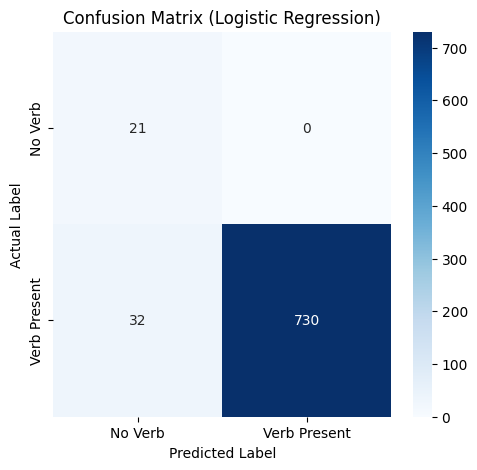

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns


# Plot Confusion Matrix for Logistic Regression
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, plot 1
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Verb', 'Verb Present'],
            yticklabels=['No Verb', 'Verb Present'])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix (Logistic Regression)")
